# 03 — Figure 4 | Pathway Enrichment Analysis

Pathway enrichment analysis for **positive hits** in the LB + 4% NaCl condition.  
Genes with `gene_call == 'Unknown'` are excluded from both numerator and background.

**Panel 4a** — Scatter plot of enrichment score vs. −log₁₀(Fisher q); dot size encodes gene-set size.  
**Panel 4b** — Heatmap of LMER estimates across the pioneer panel for all orthogroups in the Peptidoglycan biosynthesis pathway.  
**Panel 4c** — Same heatmap filtered to orthogroups containing at least one gene with a significant positive effect (lmer q < 0.05, estimate > 0).

## Configuration

In [1]:
from pathlib import Path

# --- data directory (populate yourself -- see README's Data section) ---
DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --- paths ---
DATA_PATH = DATA_DIR / "gene_fitness_lmm_results.parquet"
KEIO_FITNESS_PATH = DATA_DIR / "keio_fitness.tsv"

# --- analysis parameters ---
CONDITION  = "LB_4_salt"
KEGG_BASE  = "https://rest.kegg.jp"
N_PERMS    = 1000
Q_CUTOFF   = 0.05

# --- peptidoglycan pathway KEGG ID ---
PG_PATHWAY_ID = "path:eco00550"


## Load data

In [2]:
import re
import textwrap

import requests

import numpy as np
import pandas as pd
from scipy.stats import fisher_exact, false_discovery_control
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm

df_raw = pd.read_parquet(DATA_PATH)


def genome_label(s):
    return " ".join(s.split("_")[:2])


# Background: protein-coding genes with a definitive call in the target condition
df = (
    df_raw[
        (df_raw["condition"] == CONDITION) &
        (df_raw["gene_biotype"] == "protein_coding") &
        (df_raw["gene_call"].isin(["Hit", "Not Hit"]))
    ]
    .copy()
)
df["is_pos_hit"] = (df["gene_call"] == "Hit") & (df["lmer_estimate"] > 0)
df["label"] = df["pioneer_genome"].apply(genome_label)

print(f"Background genes ({CONDITION}, protein_coding, gene_call ∈ {{Hit, Not Hit}}): {len(df):,}")
print(f"  Positive hits (lmer_estimate > 0): {df['is_pos_hit'].sum():,}")
print(f"  Not Hit:                           {(df['gene_call'] == 'Not Hit').sum():,}")

/home/jupyter-nathan-d-hicks/.conda/envs/ppat-019/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Background genes (LB_4_salt, protein_coding, gene_call ∈ {Hit, Not Hit}): 38,865
  Positive hits (lmer_estimate > 0): 200
  Not Hit:                           38,557


## Map orthogroup → b-number (singleton orthogroups only)

E. coli rows in the dataset carry both `orthogroup` and `locus_tag` (b-number).
Each gene is mapped to a b-number via its orthogroup, but only when that orthogroup
contains **exactly one** E. coli gene. Orthogroups with zero or multiple E. coli genes
are left unmapped (NaN) to avoid ambiguity.

In [3]:
# Build orthogroup → single E. coli b-number map.
# Only orthogroups with exactly one E. coli locus_tag are mapped; others → NaN.
ecoli_og = (
    df_raw[
        (df_raw["species_name"] == "Escherichia coli") &
        df_raw["locus_tag"].notna() &
        df_raw["orthogroup"].notna()
    ]
    [["orthogroup", "locus_tag"]]
    .drop_duplicates()
)

og_ecoli_count = ecoli_og.groupby("orthogroup")["locus_tag"].nunique()
singleton_ogs  = og_ecoli_count[og_ecoli_count == 1].index

og_to_bnum = (
    ecoli_og[ecoli_og["orthogroup"].isin(singleton_ogs)]
    .set_index("orthogroup")["locus_tag"]
    .to_dict()
)

df["e_coli_bnum"] = df["orthogroup"].map(og_to_bnum)

n_mapped     = df["e_coli_bnum"].notna().sum()
n_pos_mapped = (df["is_pos_hit"] & df["e_coli_bnum"].notna()).sum()
print(f"Genes with b-number:          {n_mapped:,} / {len(df):,} ({n_mapped/len(df):.1%})")
print(f"Positive hits with b-number:  {n_pos_mapped:,} / {df['is_pos_hit'].sum():,} ({n_pos_mapped/df['is_pos_hit'].sum():.1%})")

Genes with b-number:          14,121 / 38,865 (36.3%)
Positive hits with b-number:  121 / 200 (60.5%)


## E. coli orthogroup membership

Do hits preferentially belong to orthogroups that have an E. coli homolog?
Broken out per species (Figure 4S), ordered by patristic distance from E. coli, we test
this directly. Pooled across the pioneer panel (Figure 4e), we ask the complementary
question: is the hit rate different between genes with vs. without an E. coli homolog?

In [4]:
# --- E. coli orthogroups present in this condition ---
e_coli_orthogroups = (
    df_raw[
        (df_raw["condition"] == CONDITION) &
        (df_raw["species_name"] == "Escherichia coli")
    ]["orthogroup"].dropna().unique()
)
df["in_Ecoli"] = df["orthogroup"].isin(e_coli_orthogroups)

# --- patristic distance to E. coli ---
distance_to_ecoli = pd.read_csv(
    RESULTS_DIR / "pioneer_genome_gtdb_phylogeny.tsv", sep="\t"
)[["pioneer_genome", "distance_to_ecoli"]]

print(f"{int(df['in_Ecoli'].sum()):,} / {len(df):,} genes in an E. coli orthogroup")
print(f"{len(e_coli_orthogroups):,} unique E. coli orthogroups")


def pval_label(p):
    if p < 0.0001: return "****"
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"

21,811 / 38,865 genes in an E. coli orthogroup
3,384 unique E. coli orthogroups


## Figure 4e — Hit rate by E. coli homolog status (pooled)

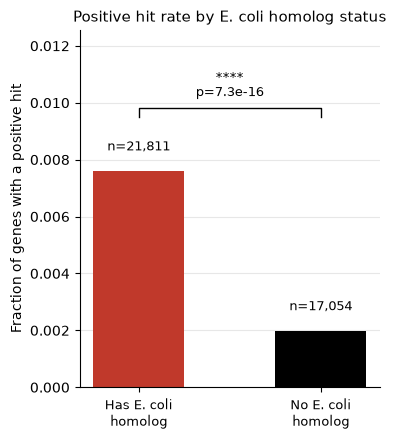

In [5]:
pool = (
    df
    .groupby("in_Ecoli", sort=False)
    .agg(n_genes=("gene_id", "count"), n_hit=("is_pos_hit", "sum"))
    .assign(frac_hit=lambda d: d["n_hit"] / d["n_genes"])
    .reindex([True, False])
    .rename(index={True: "Has E. coli homolog", False: "No E. coli homolog"})
    .rename_axis("homolog_status")
    .reset_index()
)

has_hom = pool[pool["homolog_status"] == "Has E. coli homolog"].iloc[0]
no_hom  = pool[pool["homolog_status"] == "No E. coli homolog"].iloc[0]
table   = [[int(has_hom["n_hit"]), int(has_hom["n_genes"] - has_hom["n_hit"])],
           [int(no_hom["n_hit"]),  int(no_hom["n_genes"]  - no_hom["n_hit"])]]
_, p_pool = fisher_exact(table, alternative="two-sided")

COLORS_POOL = {"Has E. coli homolog": "#C0392B", "No E. coli homolog": "black"}
X_LABELS = {
    "Has E. coli homolog": "Has E. coli\nhomolog",
    "No E. coli homolog": "No E. coli\nhomolog",
}

ymax = pool["frac_hit"].max()
ypad = max(ymax * 0.25, 0.001)
tick_h = ypad * 0.15
y_bracket = ymax + ypad

fig, ax = plt.subplots(figsize=(4, 4.5))
bars = ax.bar(
    pool["homolog_status"], pool["frac_hit"],
    color=[COLORS_POOL[c] for c in pool["homolog_status"]],
    width=0.5, zorder=2,
)
for bar, row in zip(bars, pool.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + ymax * 0.08,
        f"n={int(row.n_genes):,}",
        ha="center", va="bottom", fontsize=9,
    )

ax.plot(
    [0, 0, 1, 1],
    [y_bracket, y_bracket + tick_h, y_bracket + tick_h, y_bracket],
    color="black", lw=1,
)
ax.text(
    0.5, y_bracket + tick_h + ypad * 0.15,
    f"{pval_label(p_pool)}\np={p_pool:.2g}",
    ha="center", va="bottom", fontsize=9,
)

ax.set_ylabel("Fraction of genes with a positive hit", fontsize=10)
ax.set_ylim(0, y_bracket + ypad * 1.6)
ax.set_title("Positive hit rate by E. coli homolog status", fontsize=11)
ax.set_xticks(range(len(pool)))
ax.set_xticklabels([X_LABELS[l] for l in pool["homolog_status"]], fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3, zorder=0)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "figure4b_ecoli_orthogroup_membership_pooled.pdf", bbox_inches="tight")
plt.show()


## Figure 4f — E. coli orthogroup essentiality of hits

For each positive hit, classify its E. coli orthogroup homolog(s) as essential, non-essential,
or mixed based on KEIO fitness data. Genes with no E. coli orthogroup are labelled "No homolog".

Total positive hits:     200
  Essential homolog:     35  (17.5%)
  Non-essential homolog: 121  (60.5%)
  Mixed homolog:         10  (5.0%)
  No homolog:            34  (17.0%)


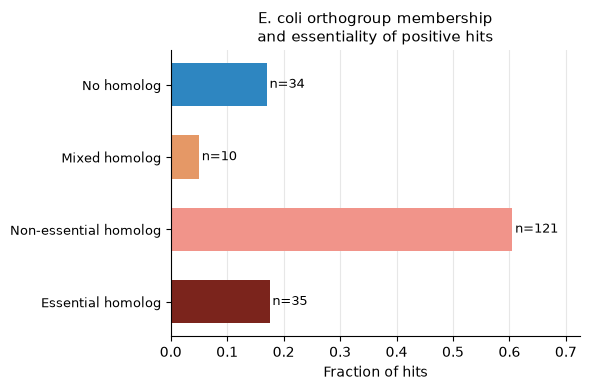

In [8]:
# --- E. coli gene essentiality lookup ---
ecoli_rows = df_raw[
    df_raw["species_name"].str.contains("Escherichia coli", na=False)
].drop_duplicates("protein_id").copy()

keio_df = pd.read_csv(KEIO_FITNESS_PATH, sep="\t", usecols=["locusId", "sysName"])
keio_nonessential = set(keio_df["sysName"].dropna())

ecoli_rows["is_essential"] = (
    ecoli_rows["locus_tag"].notna() &
    ~ecoli_rows["locus_tag"].isin(keio_nonessential)
)

# --- Build orthogroup → essentiality profile for all E. coli members ---
og_ecoli_ess = (
    ecoli_rows.dropna(subset=["orthogroup"])
    .groupby("orthogroup")["is_essential"]
    .apply(list)
)

# --- Classify hits by orthogroup membership and E. coli essentiality ---
def classify_hit(og):
    if pd.isna(og) or og not in og_ecoli_ess.index:
        return "No homolog"
    ess_list = og_ecoli_ess[og]
    if all(ess_list):
        return "Essential homolog"
    elif not any(ess_list):
        return "Non-essential homolog"
    else:
        return "Mixed homolog"

hits = df[df["is_pos_hit"]].copy()
hits["ecoli_category"] = hits["orthogroup"].map(classify_hit)

cat_counts = hits["ecoli_category"].value_counts()
n_total  = len(hits)
n_ess    = cat_counts.get("Essential homolog", 0)
n_noness = cat_counts.get("Non-essential homolog", 0)
n_mixed  = cat_counts.get("Mixed homolog", 0)
n_novel  = cat_counts.get("No homolog", 0)

assert n_ess + n_noness + n_mixed + n_novel == n_total, "counts do not sum to total"

print(f"Total positive hits:     {n_total:,}")
print(f"  Essential homolog:     {n_ess:,}  ({n_ess/n_total:.1%})")
print(f"  Non-essential homolog: {n_noness:,}  ({n_noness/n_total:.1%})")
print(f"  Mixed homolog:         {n_mixed:,}  ({n_mixed/n_total:.1%})")
print(f"  No homolog:            {n_novel:,}  ({n_novel/n_total:.1%})")

# --- plot ---
COLOR_ESS    = "#7B241C"
COLOR_NONESS = "#F1948A"
COLOR_MIXED  = "#E59866"
COLOR_NOVEL  = "#2E86C1"

CATEGORY_ORDER = ["Essential homolog", "Non-essential homolog", "Mixed homolog", "No homolog"]
fracs  = [n_ess / n_total, n_noness / n_total, n_mixed / n_total, n_novel / n_total]
counts = [n_ess, n_noness, n_mixed, n_novel]
colors = [COLOR_ESS, COLOR_NONESS, COLOR_MIXED, COLOR_NOVEL]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(CATEGORY_ORDER, fracs, color=colors, height=0.6, zorder=2)

for bar, n in zip(bars, counts):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"n={n:,}",
        ha="left", va="center", fontsize=9,
    )

ax.set_xlabel("Fraction of hits", fontsize=10)
ax.set_xlim(0, max(fracs) + 0.12)
ax.set_title("E. coli orthogroup membership\nand essentiality of positive hits", fontsize=11)
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.3, zorder=0)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "figure4a_hits_ecoli_essentiality.pdf", bbox_inches="tight")
plt.show()


## Fetch KEGG pathway annotations

In [9]:
resp = requests.get(f"{KEGG_BASE}/list/pathway/eco")
resp.raise_for_status()
pathway_name_map = {}
for line in resp.text.strip().splitlines():
    pid, name = line.split("\t", 1)
    pathway_name_map[f"path:{pid.strip()}"] = name.strip()

resp = requests.get(f"{KEGG_BASE}/link/pathway/eco")
resp.raise_for_status()
bnum_to_pathways = {}
for line in resp.text.strip().splitlines():
    gene_id, pathway_id = line.split("\t")
    bnum = gene_id.strip().replace("eco:", "")
    bnum_to_pathways.setdefault(bnum, []).append(pathway_id.strip())

print(f"Loaded {len(pathway_name_map):,} E. coli KEGG pathway definitions")
print(f"Gene-pathway associations for {len(bnum_to_pathways):,} E. coli genes")

Loaded 138 E. coli KEGG pathway definitions
Gene-pathway associations for 1,787 E. coli genes


## Pooled enrichment analysis

**Numerator:** positive hits (`gene_call == 'Hit'` and `lmer_estimate > 0`)  
**Denominator (universe):** all background genes with a b-number assignment

**Greedy collapse:** multiple pioneer genes mapping to the same b-number are collapsed;
the b-number is enriched if *any* gene across all species is a positive hit.

**Tests:** one-sided Fisher's exact (greater) + gene-label permutation test (N=1000),
both BH-corrected across all pathways.

In [10]:
# Assign KEGG pathways and explode to one row per gene × pathway
df_kegg = df.dropna(subset=["e_coli_bnum"]).copy()
df_kegg["pathway_ids"] = df_kegg["e_coli_bnum"].map(bnum_to_pathways)

df_exploded = (
    df_kegg.dropna(subset=["pathway_ids"])
    .explode("pathway_ids")
    .rename(columns={"pathway_ids": "pathway_id"})
)
df_exploded["pathway_name"] = df_exploded["pathway_id"].map(pathway_name_map)

print(f"Genes with KEGG pathway annotation:          {df_exploded['gene_id'].nunique():,}")
print(f"Positive hits with KEGG pathway annotation:  {df_exploded[df_exploded['is_pos_hit']]['gene_id'].nunique():,}")

Genes with KEGG pathway annotation:          7,097
Positive hits with KEGG pathway annotation:  52


In [11]:
# Greedy collapse: per-pathway per-bnum → enriched if any gene is a positive hit
df_greedy = (
    df_exploded
    .groupby(["pathway_id", "e_coli_bnum"], sort=False)["is_pos_hit"]
    .any()
    .reset_index()
)

# Universe: ALL b-number-mapped genes, regardless of pathway annotation.
bnum_enriched = df_kegg.groupby("e_coli_bnum")["is_pos_hit"].any()
N = len(bnum_enriched)
K = int(bnum_enriched.sum())

# Per-pathway Fisher's exact test
fisher_rows = []
for pathway_id, grp in df_greedy.groupby("pathway_id"):
    n = len(grp)
    k = int(grp["is_pos_hit"].sum())
    table = [[k, n - k], [K - k, N - n - K + k]]
    or_val, p = fisher_exact(table, alternative="greater")
    fisher_rows.append({
        "pathway_id":   pathway_id,
        "pathway_name": pathway_name_map.get(pathway_id, pathway_id),
        "n_in_pathway": n,
        "n_pos_hit":    k,
        "odds_ratio":   or_val,
        "fisher_p":     p,
    })

df_primary = pd.DataFrame(fisher_rows)
df_primary["fisher_q"]        = false_discovery_control(df_primary["fisher_p"], method="bh")
df_primary["enrichment_score"] = df_primary["n_pos_hit"] / df_primary["n_in_pathway"]
df_primary = df_primary.sort_values("fisher_q").reset_index(drop=True)

print(f"Universe: {N:,} unique b-numbers, {K:,} positive hits ({K/N:.1%})")
print(f"Significant pathways (Fisher q < {Q_CUTOFF}): {(df_primary['fisher_q'] < Q_CUTOFF).sum()}")

Universe: 2,698 unique b-numbers, 86 positive hits (3.2%)
Significant pathways (Fisher q < 0.05): 1


In [ ]:
# Permutation test — shuffle positive-hit label at the b-number level
unique_bnums   = list(bnum_enriched.index)
bnum_to_idx    = {b: i for i, b in enumerate(unique_bnums)}
bnum_hit_arr   = bnum_enriched.reindex(unique_bnums).values.astype(bool)
row_bnum_idx   = df_greedy["e_coli_bnum"].map(bnum_to_idx).values

pathway_row_map = (
    df_greedy
    .assign(_row=np.arange(len(df_greedy)))
    .groupby("pathway_id")["_row"]
    .apply(np.array)
    .to_dict()
)
pathway_totals  = {pid: len(idxs) for pid, idxs in pathway_row_map.items()}
observed_scores = df_primary.set_index("pathway_id")["enrichment_score"].to_dict()
pathway_id_list = list(pathway_row_map.keys())

perm_ge = np.zeros(len(pathway_id_list), dtype=int)
rng = np.random.default_rng(42)

for _ in tqdm(range(N_PERMS), desc="Permutations"):
    shuffled   = bnum_hit_arr[rng.permutation(len(unique_bnums))]
    row_is_hit = shuffled[row_bnum_idx]
    for i, pid in enumerate(pathway_id_list):
        perm_score = row_is_hit[pathway_row_map[pid]].sum() / pathway_totals[pid]
        if perm_score >= observed_scores.get(pid, np.inf):
            perm_ge[i] += 1

df_perm = pd.DataFrame({"pathway_id": pathway_id_list, "perm_p": perm_ge / N_PERMS})
df_perm["perm_q"] = false_discovery_control(df_perm["perm_p"], method="bh")

df_primary = df_primary.merge(df_perm, on="pathway_id", how="left").sort_values("fisher_q").reset_index(drop=True)
print(f"Significant (perm q < {Q_CUTOFF}): {(df_primary['perm_q'] < Q_CUTOFF).sum()}")

# Save pooled results
out_path = RESULTS_DIR / "pathway_enrichment_pooled.tsv"
df_primary.to_csv(out_path, sep="\t", index=False)
print(f"Saved {len(df_primary):,} pathways to {out_path}")

## Figure 4a — Enrichment score vs. Fisher q

Each dot is a KEGG pathway. x-axis: fraction of E. coli pathway genes that are positive
hits (enrichment score). y-axis: −log₁₀(Fisher q). Dot area ∝ √(gene-set size).

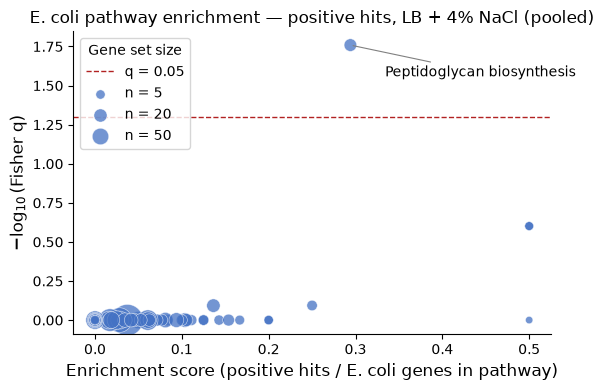

In [13]:
neg_log_q = -np.log10(df_primary["fisher_q"].clip(lower=1e-10))
sizes     = np.sqrt(df_primary["n_in_pathway"]) * 20

fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(
    df_primary["enrichment_score"],
    neg_log_q,
    s=sizes,
    alpha=0.75,
    color="#4472C4",
    edgecolors="white",
    linewidths=0.4,
    zorder=2,
)
ax.axhline(
    -np.log10(Q_CUTOFF),
    color="firebrick", linestyle="--", linewidth=1,
    label=f"q = {Q_CUTOFF}", zorder=1,
)

# Label the most significant pathway
top       = df_primary.iloc[0]
top_x     = top["enrichment_score"]
top_y     = -np.log10(max(top["fisher_q"], 1e-10))
top_label = re.sub(r"\s*-\s*Escherichia coli.*$", "", top["pathway_name"])
ax.annotate(
    top_label,
    xy=(top_x, top_y),
    xytext=(top_x + 0.04, top_y - 0.2),
    fontsize=10,
    ha="left",
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.8),
)

# Size legend
for n_leg in [5, 20, 50]:
    ax.scatter([], [], s=np.sqrt(n_leg) * 20, color="#4472C4", alpha=0.75,
               edgecolors="white", linewidths=0.4, label=f"n = {n_leg}")

ax.set_xlabel("Enrichment score (positive hits / E. coli genes in pathway)", fontsize=12)
ax.set_ylabel(r"$-\log_{10}$(Fisher q)", fontsize=12)
ax.set_title("E. coli pathway enrichment — positive hits, LB + 4% NaCl (pooled)", fontsize=12)
ax.legend(title="Gene set size", fontsize=10, title_fontsize=10, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "figure4c_pathway_enrichment_scatter.pdf", bbox_inches="tight")
plt.show()

## Peptidoglycan pathway — heatmap setup

For each orthogroup in the peptidoglycan pathway, take the gene with the highest
LMER estimate per species (greedy representative). Columns = E. coli gene symbols
for that orthogroup; rows = pioneer genomes sorted by phylum then species.

In [14]:
PHYLUM_COLORS = {
    "p__Pseudomonadota": "#4472C4",
    "p__Bacillota":      "#70AD47",
    "p__Actinomycetota": "#ED7D31",
    "p__Deinococcota":   "#C00000",
}
PHYLUM_ORDER = ["p__Bacillota", "p__Actinomycetota", "p__Deinococcota", "p__Pseudomonadota"]

# Phylum map from Figure 1 output (pioneer_genome_gtdb_phylogeny.tsv)
genome_map_pg = pd.read_csv(RESULTS_DIR / "pioneer_genome_gtdb_phylogeny.tsv", sep="\t")
genome_map_pg["label"] = genome_map_pg["pioneer_genome"].apply(genome_label)
species_to_phylum = genome_map_pg.set_index("label")["gtdb_phylum"].to_dict()

# --- 1. Orthogroups in the peptidoglycan pathway ---
pg_exploded    = df_exploded[df_exploded["pathway_id"] == PG_PATHWAY_ID].copy()
pg_orthogroups = pg_exploded["orthogroup"].dropna().unique()

# --- 2. Comma-separated E. coli gene_bionames per orthogroup (column headers) ---
ecoli_og_names = (
    df_raw[
        (df_raw["species_name"] == "Escherichia coli") &
        df_raw["orthogroup"].isin(pg_orthogroups) &
        df_raw["gene_bioname"].notna()
    ]
    .groupby("orthogroup")["gene_bioname"]
    .apply(lambda x: ", ".join(sorted(x.dropna().unique())))
    .to_dict()
)

# --- 3. All background genes in these orthogroups ---
pg_all  = df[df["orthogroup"].isin(pg_orthogroups)].copy()

# Best representative per species × orthogroup: highest lmer_estimate
pg_best = (
    pg_all
    .sort_values("lmer_estimate", ascending=False)
    .groupby(["label", "orthogroup"], as_index=False)
    .first()
)

# --- 4. Pivot to species × orthogroup matrix ---
pivot_est = pg_best.pivot(index="label", columns="orthogroup", values="lmer_estimate")
pivot_q   = pg_best.pivot(index="label", columns="orthogroup", values="lmer_q_value")

# Rename columns to E. coli gene names
col_name_map = {og: ecoli_og_names.get(og, og) for og in pivot_est.columns}
pivot_est.rename(columns=col_name_map, inplace=True)
pivot_q.rename(columns=col_name_map, inplace=True)

# --- 5. Sort rows by phylum then species ---
pivot_est["_phylum"] = pivot_est.index.map(species_to_phylum)
pivot_est = (
    pivot_est
    .assign(_phylum_rank=lambda d: d["_phylum"].map({p: i for i, p in enumerate(PHYLUM_ORDER)}).fillna(99))
    .sort_values(["_phylum_rank", "_phylum"])
    .drop(columns=["_phylum", "_phylum_rank"])
)
pivot_q = pivot_q.loc[pivot_est.index]

# Sort columns by mean estimate descending
col_order = pivot_est.mean(skipna=True).sort_values(ascending=False).index
pivot_est = pivot_est[col_order]
pivot_q   = pivot_q[col_order]

n_rows, n_cols = pivot_est.shape
print(f"Heatmap: {n_rows} species × {n_cols} orthogroups")
print(f"Missing cells: {pivot_est.isna().sum().sum()} / {n_rows * n_cols}")

Heatmap: 11 species × 17 orthogroups
Missing cells: 54 / 187


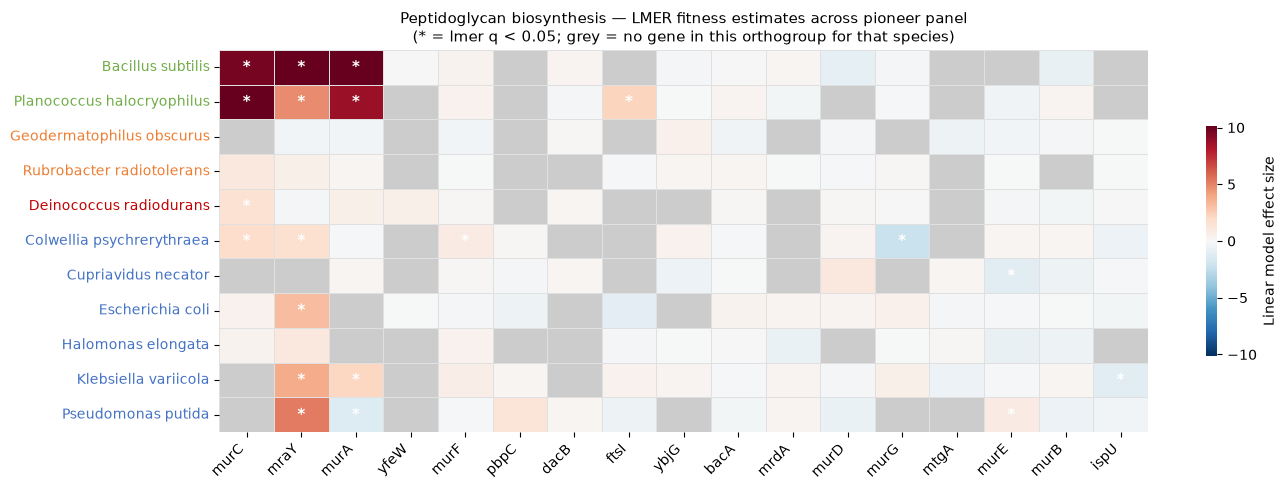

In [15]:
def _draw_pg_heatmap(pivot_est, pivot_q, ax, title):
    """Shared drawing logic for the peptidoglycan heatmap."""
    ax.set_facecolor("#CCCCCC")
    vmax = np.nanpercentile(np.abs(pivot_est.values), 98)

    sns.heatmap(
        pivot_est,
        ax=ax,
        cmap=plt.cm.RdBu_r.copy(),
        center=0,
        vmin=-vmax, vmax=vmax,
        linewidths=0.4,
        linecolor="#e0e0e0",
        mask=pivot_est.isna(),
        cbar_kws={"label": "Linear model effect size", "shrink": 0.6},
        annot=False,
    )

    # Asterisks on significant cells
    for r, row_label in enumerate(pivot_est.index):
        for c, col_label in enumerate(pivot_est.columns):
            est   = pivot_est.loc[row_label, col_label]
            q_val = pivot_q.loc[row_label, col_label] if row_label in pivot_q.index else np.nan
            if pd.notna(est) and pd.notna(q_val) and q_val < 0.05:
                ax.text(c + 0.5, r + 0.5, "*",
                        ha="center", va="center", fontsize=11,
                        color="white", fontweight="bold")

    # Color y-axis labels by phylum
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
    for label_obj in ax.get_yticklabels():
        phylum = species_to_phylum.get(label_obj.get_text(), "")
        label_obj.set_color(PHYLUM_COLORS.get(phylum, "black"))

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(title, fontsize=11)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)


## Figure 4c — Peptidoglycan heatmap (orthogroups with ≥1 significant positive hit)

Columns are retained only when at least one cell in that orthogroup has
`lmer_estimate > 0` and `lmer_q_value < 0.05`.

Orthogroups retained: 6 / 17


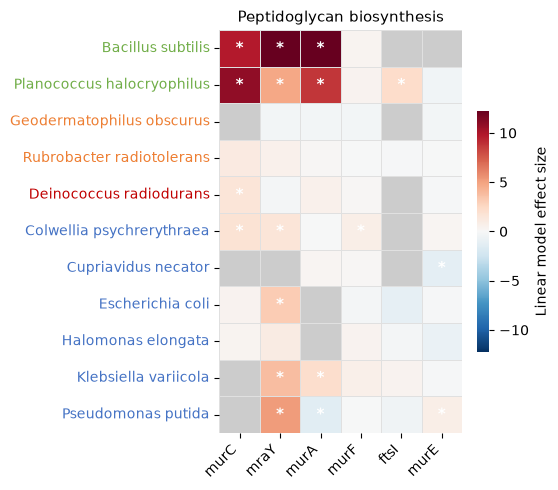

In [16]:
# Identify orthogroups with ≥1 significant positive effect
sig_pos_cols = (
    (pivot_est > 0) & (pivot_q < 0.05)
).any(axis=0)

pivot_est_filt = pivot_est.loc[:, sig_pos_cols]
pivot_q_filt   = pivot_q.loc[:, sig_pos_cols]

print(f"Orthogroups retained: {sig_pos_cols.sum()} / {len(sig_pos_cols)}")

fig, ax = plt.subplots(figsize=(5.5, 5))
_draw_pg_heatmap(
    pivot_est_filt, pivot_q_filt, ax,
    title=(
        "Peptidoglycan biosynthesis"
    )
)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "figure4d_peptidoglycan_heatmap_small.pdf", bbox_inches="tight")
plt.show()


## Figure 4d — COG category enrichment (positive hits)

In [17]:
COG_CATEGORY_NAMES = {
    "A": "RNA processing and modification",
    "B": "Chromatin structure and dynamics",
    "C": "Energy production and conversion",
    "D": "Cell cycle control, cell division, chromosome partitioning",
    "E": "Amino acid transport and metabolism",
    "F": "Nucleotide transport and metabolism",
    "G": "Carbohydrate transport and metabolism",
    "H": "Coenzyme transport and metabolism",
    "I": "Lipid transport and metabolism",
    "J": "Translation, ribosomal structure and biogenesis",
    "K": "Transcription",
    "L": "Replication, recombination and repair",
    "M": "Cell wall/membrane/envelope biogenesis",
    "N": "Cell motility",
    "O": "Post-translational modification, protein turnover, chaperones",
    "P": "Inorganic ion transport and metabolism",
    "Q": "Secondary metabolites biosynthesis, transport and catabolism",
    "R": "General function prediction only",
    "S": "Function unknown",
    "T": "Signal transduction mechanisms",
    "U": "Intracellular trafficking, secretion, and vesicular transport",
    "V": "Defense mechanisms",
    "W": "Extracellular structures",
    "X": "Mobilome: prophages, transposons",
    "Y": "Nuclear structure",
    "Z": "Cytoskeleton",
}

# --- per-COG hit counts (positive hits vs all analyzed genes) ---
df_cog = df.copy()
df_cog["COG_category"] = df_cog["COG_category"].fillna("S")


cog_counts = []
for cog_letter in COG_CATEGORY_NAMES.keys():
    df_cog_sub = df_cog[df_cog["COG_category"].apply(lambda x: cog_letter in x)]
    if len(df_cog_sub) > 0:
        cog_counts.append({"COG_category": cog_letter, "n_analyzed_genes": df_cog_sub.gene_id.nunique(), "n_hits": df_cog_sub.is_pos_hit.sum()})
    
cog_counts = pd.DataFrame(cog_counts)
cog_counts["n_not_hits"] = cog_counts["n_analyzed_genes"] - cog_counts["n_hits"]
cog_counts


,COG_category,n_analyzed_genes,n_hits,n_not_hits
0,A,10,0,10
1,B,18,0,18
2,C,2769,5,2764
3,D,382,3,379
4,E,3352,19,3333
5,F,1105,13,1092
6,G,2326,7,2319
7,H,1439,7,1432
8,I,1479,3,1476
9,J,1596,6,1590


In [18]:
# Restrict to single-letter categories with ≥100 analyzed genes
cog_wide = cog_counts[
    (cog_counts["COG_category"].str.len() == 1) &
    (cog_counts["n_analyzed_genes"] >= 100)
].copy()

N = df_cog["gene_id"].nunique()
K = df_cog["is_pos_hit"].sum()

# --- Fisher's exact (one-sided greater) per COG vs the rest ---
cog_fisher = []
for cog in cog_wide["COG_category"]:
    row      = cog_wide[cog_wide["COG_category"] == cog].iloc[0]
    table    = [
        [int(row["n_hits"]),       int(row["n_not_hits"])],
        [int(K - row["n_hits"]),   int(N - row["n_analyzed_genes"] - K + row["n_hits"])],
    ]
    _, p = fisher_exact(table, alternative="greater")
    cog_fisher.append({"COG_category": cog, "fisher_p": p,
                       "n_analyzed_genes": row["n_analyzed_genes"],
                       "n_hits": row["n_hits"],
                       "n_not_hits": row["n_not_hits"]})

cog_fisher_df = pd.DataFrame(cog_fisher)
cog_fisher_df["fisher_q"] = false_discovery_control(cog_fisher_df["fisher_p"], method="bh")

cog_fisher_df


,COG_category,fisher_p,n_analyzed_genes,n_hits,n_not_hits,fisher_q
0,C,0.998895,2769,5,2764,1.000000
1,D,0.313982,382,3,379,1.000000
2,E,0.364418,3352,19,3333,1.000000
3,F,0.004984,1105,13,1092,0.031565
4,G,0.958378,2326,7,2319,1.000000
5,H,0.612954,1439,7,1432,1.000000
6,I,0.983106,1479,3,1476,1.000000
7,J,0.833858,1596,6,1590,1.000000
8,K,0.000433,3326,32,3294,0.004118
9,L,0.849349,1633,6,1627,1.000000


In [19]:
cog_wide = cog_wide.merge(cog_fisher_df, on=["COG_category", "n_analyzed_genes", "n_hits", "n_not_hits"], how="left")
cog_wide["enrichment_score"] = cog_wide["n_hits"] / cog_wide["n_analyzed_genes"]
cog_wide["neg_log_q"]        = -np.log10(cog_wide["fisher_q"].clip(lower=1e-10))
cog_wide["category_name"]    = cog_wide["COG_category"].map(COG_CATEGORY_NAMES).fillna("Unknown")

print(f"COG categories tested: {len(cog_wide)}")
print(f"Significant (q < {Q_CUTOFF}): {(cog_wide['fisher_q'] < Q_CUTOFF).sum()}")

cog_wide

COG categories tested: 19
Significant (q < 0.05): 3


,COG_category,n_analyzed_genes,n_hits,n_not_hits,fisher_p,fisher_q,enrichment_score,neg_log_q,category_name
0,C,2769,5,2764,0.998895,1.000000,0.001806,-0.000000,Energy production and conversion
1,D,382,3,379,0.313982,1.000000,0.007853,-0.000000,"Cell cycle control, cell division, chromosome ..."
2,E,3352,19,3333,0.364418,1.000000,0.005668,-0.000000,Amino acid transport and metabolism
3,F,1105,13,1092,0.004984,0.031565,0.011765,1.500799,Nucleotide transport and metabolism
4,G,2326,7,2319,0.958378,1.000000,0.003009,-0.000000,Carbohydrate transport and metabolism
5,H,1439,7,1432,0.612954,1.000000,0.004864,-0.000000,Coenzyme transport and metabolism
6,I,1479,3,1476,0.983106,1.000000,0.002028,-0.000000,Lipid transport and metabolism
7,J,1596,6,1590,0.833858,1.000000,0.003759,-0.000000,"Translation, ribosomal structure and biogenesis"
8,K,3326,32,3294,0.000433,0.004118,0.009621,2.385331,Transcription
9,L,1633,6,1627,0.849349,1.000000,0.003674,-0.000000,"Replication, recombination and repair"


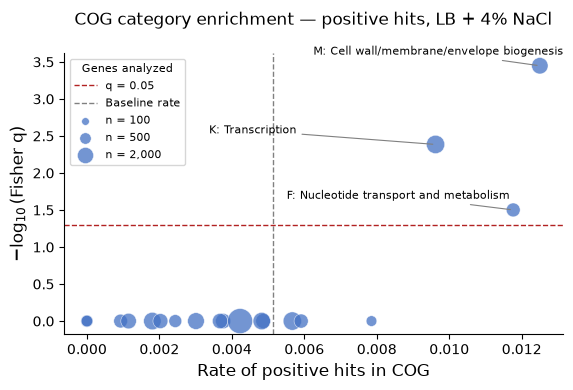

In [20]:
sizes = np.sqrt(cog_wide["n_analyzed_genes"]) * 3

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(
    cog_wide["enrichment_score"],
    cog_wide["neg_log_q"],
    s=sizes,
    alpha=0.75,
    color="#4472C4",
    edgecolors="white",
    linewidths=0.4,
    zorder=2,
)
ax.axhline(
    -np.log10(Q_CUTOFF), color="firebrick", linestyle="--",
    linewidth=1, label=f"q = {Q_CUTOFF}", zorder=1,
)
plt.axvline(x=K/N, color="gray", linestyle="--", linewidth=1, label="Baseline rate")

# Label significant COG categories
sig = cog_wide[cog_wide["fisher_q"] < Q_CUTOFF].sort_values("enrichment_score", ascending=False)
x_range = cog_wide["enrichment_score"].max() - cog_wide["enrichment_score"].min()
for _, row in sig.iterrows():
    ax.annotate(
        f"{row['COG_category']}: {row['category_name']}",
        xy=(row["enrichment_score"], row["neg_log_q"]),
        xytext=(row["enrichment_score"] - x_range * 0.5, row["neg_log_q"] + 0.15),
        fontsize=8,
        ha="left",
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.8),
    )

for n_leg in [100, 500, 2000]:
    ax.scatter([], [], s=np.sqrt(n_leg) * 3, color="#4472C4", alpha=0.75,
               edgecolors="white", linewidths=0.4, label=f"n = {n_leg:,}")

ax.set_xlabel("Rate of positive hits in COG", fontsize=12)
ax.set_ylabel(r"$-\log_{10}$(Fisher q)", fontsize=12)
ax.set_title(
    "COG category enrichment — positive hits, LB + 4% NaCl\n",
    fontsize=12,
)
ax.legend(title="Genes analyzed", fontsize=8, title_fontsize=8, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTS_DIR / "figure4e_cog_enrichment_scatter.pdf", bbox_inches="tight")
plt.show()